# Notebook 2 — Exploratory Data Analysis

## Objectives

- Load the cleaned monthly demand dataset.
- Plot monthly demand for each drug.
- Identify **trend**, **seasonality**, and **outliers**.
- Decompose each series using additive/multiplicative decomposition (seasonal period **m = 12**).
- Comment on: yearly seasonality, trend direction, variance stability.

**No modeling in this notebook—EDA only.**

## 1. Imports and Load Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.seasonal import seasonal_decompose

PROJECT_ROOT = Path(".").resolve()
if PROJECT_ROOT.name == "notebooks" and (PROJECT_ROOT.parent / "outputs").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
elif PROJECT_ROOT.name != "pharmacy_forecasting":
    PROJECT_ROOT = PROJECT_ROOT / "pharmacy_forecasting"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
DATA_PATH = OUTPUTS_DIR / "monthly_demand.csv"

df = pd.read_csv(DATA_PATH)
df["month"] = pd.to_datetime(df["month"])
df = df.sort_values(["drug_id", "month"]).reset_index(drop=True)
print("Shape:", df.shape)
df.head()

Shape: (360, 3)


,drug_id,month,monthly_demand
0,D001,2022-01-01,2216
1,D001,2022-02-01,1998
2,D001,2022-03-01,2015
3,D001,2022-04-01,3171
4,D001,2022-05-01,2914


## 2. Monthly Demand Plots per Drug

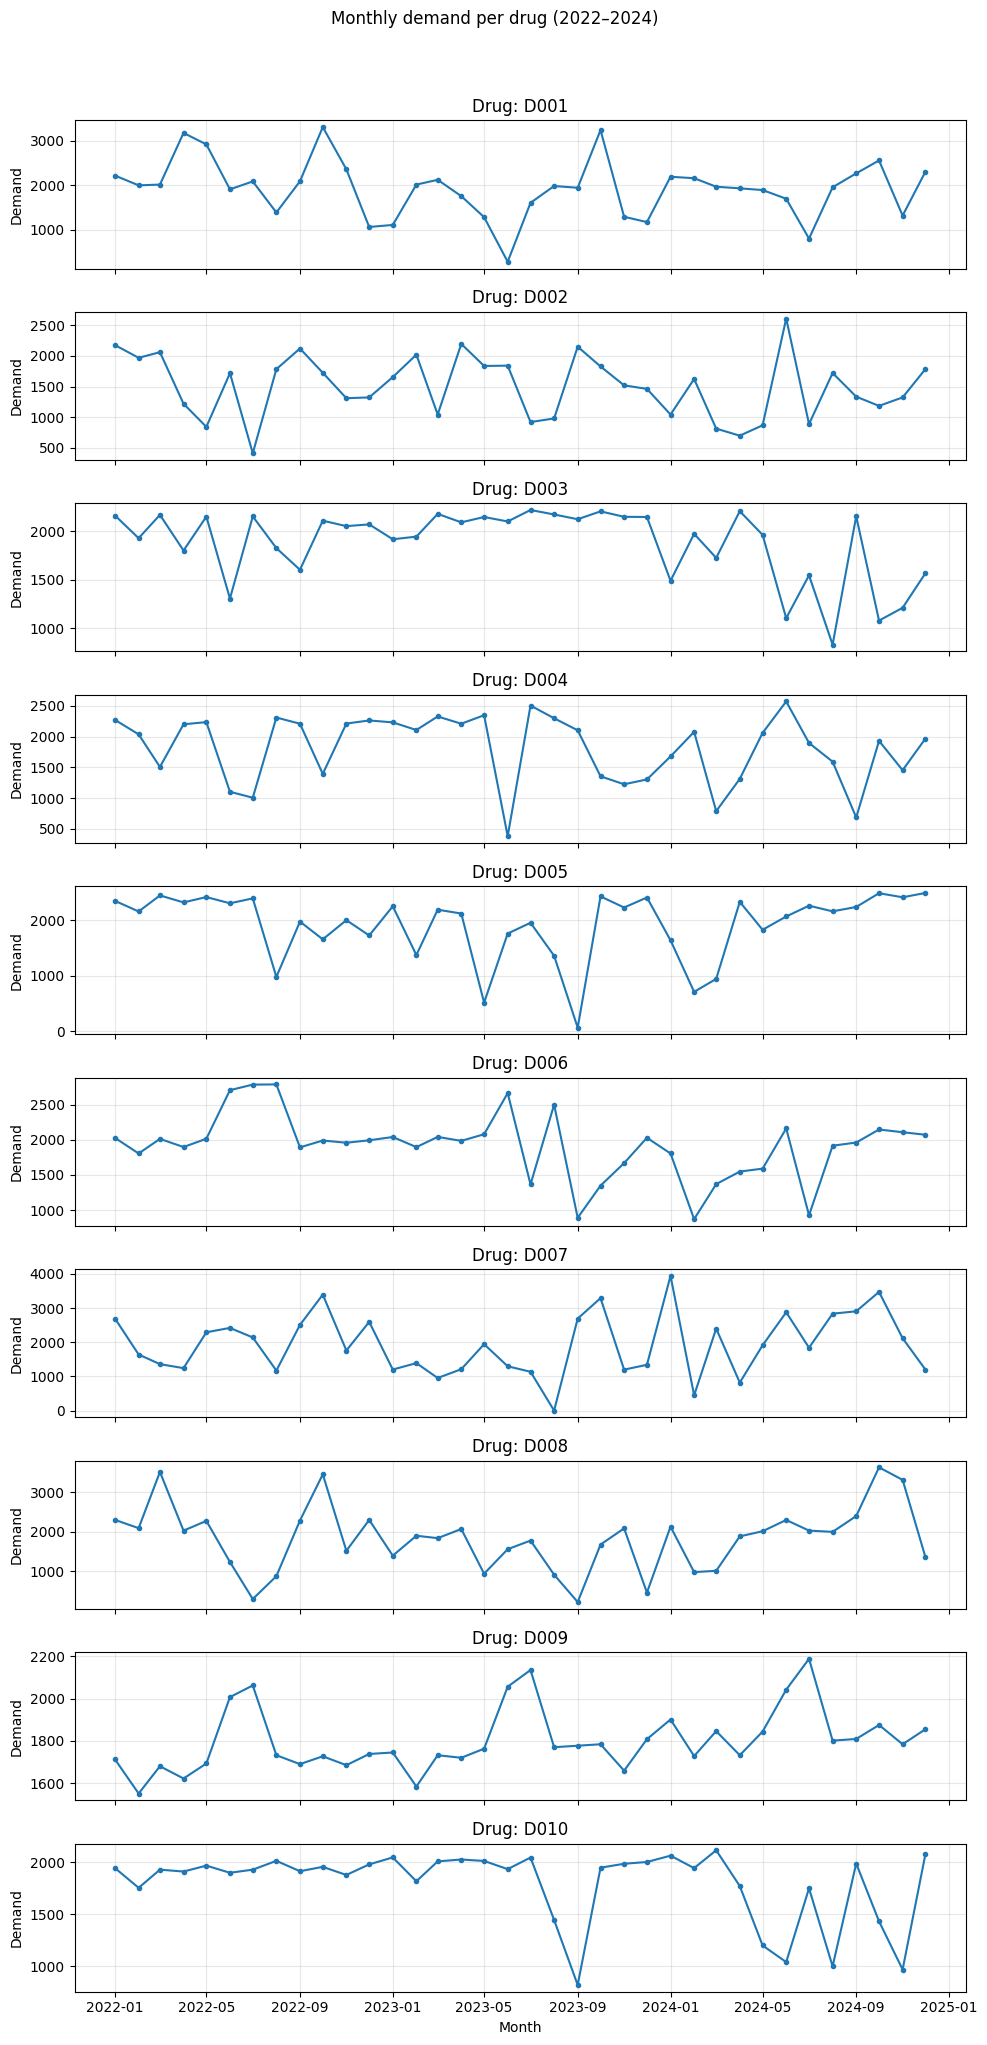

In [4]:
drug_ids = df["drug_id"].unique()
n_drugs = len(drug_ids)
fig, axes = plt.subplots(n_drugs, 1, figsize=(10, 2 * n_drugs), sharex=True)
if n_drugs == 1:
    axes = [axes]
for ax, drug_id in zip(axes, drug_ids):
    sub = df[df["drug_id"] == drug_id]
    ax.plot(sub["month"], sub["monthly_demand"], marker="o", markersize=3)
    ax.set_ylabel("Demand")
    ax.set_title(f"Drug: {drug_id}")
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("Month")
plt.suptitle("Monthly demand per drug (2022–2024)", y=1.02)
plt.tight_layout()
plt.show()

## 3. Trend, Seasonality, and Outliers — Summary

We inspect each series for:
- **Trend:** Upward/downward drift over time.
- **Seasonality:** Repeating pattern every 12 months (yearly).
- **Outliers:** Unusual spikes or drops (e.g. IQR or z-score).

In [5]:
def describe_series(series: pd.Series) -> dict:
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = ((series < lower) | (series > upper)).sum()
    return {"mean": series.mean(), "std": series.std(), "outliers_iqr": outliers}

summary = []
for drug_id in drug_ids:
    sub = df[df["drug_id"] == drug_id]["monthly_demand"]
    summary.append({"drug_id": drug_id, **describe_series(sub)})
summary_df = pd.DataFrame(summary)
summary_df

,drug_id,mean,std,outliers_iqr
0,D001,1927.194444,651.051932,4
1,D002,1499.805556,514.459207,0
2,D003,1876.805556,376.943483,1
3,D004,1810.361111,559.027582,0
4,D005,1914.277778,608.653061,3
5,D006,1913.388889,470.515722,7
6,D007,1933.944444,911.795182,0
7,D008,1837.416667,834.172109,0
8,D009,1801.027778,149.425277,4
9,D010,1792.916667,355.522583,5


## 4. Seasonal Decomposition (m = 12)

Decompose each drug's series into **trend**, **seasonal**, and **residual** using additive decomposition. Use period **m = 12** for yearly seasonality.

In [6]:
def decompose_drug(df: pd.DataFrame, drug_id: str, period: int = 12, model: str = "additive"):
    sub = df[df["drug_id"] == drug_id][["month", "monthly_demand"]].set_index("month")
    sub = sub.asfreq("MS").fillna(0)
    result = seasonal_decompose(sub["monthly_demand"], model=model, period=period, extrapolate_trend="freq")
    return result

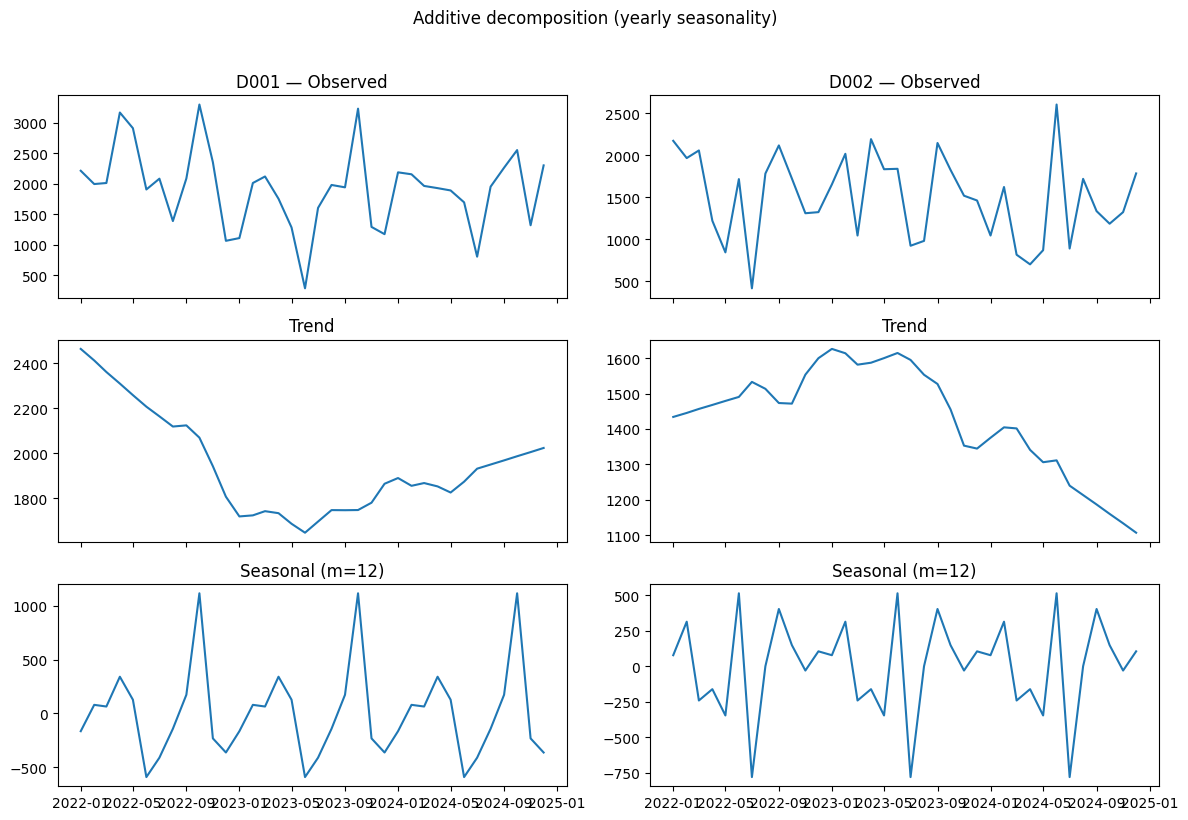

In [7]:
# Decomposition for first 2 drugs (example); repeat for others if needed
fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex="col")
for i, drug_id in enumerate(drug_ids[:2]):
    decomp = decompose_drug(df, drug_id, period=12)
    axes[0, i].plot(decomp.observed)
    axes[0, i].set_title(f"{drug_id} — Observed")
    axes[1, i].plot(decomp.trend)
    axes[1, i].set_title("Trend")
    axes[2, i].plot(decomp.seasonal)
    axes[2, i].set_title("Seasonal (m=12)")
plt.suptitle("Additive decomposition (yearly seasonality)", y=1.02)
plt.tight_layout()
plt.show()

## 5. Comments: Seasonality, Trend, Variance

- **Yearly seasonality (m = 12):** The seasonal component shows a 12-month cycle; demand varies by month within the year (e.g. higher in certain seasons).
- **Trend direction:** The trend component indicates whether demand is increasing, decreasing, or stable over 2022–2024.
- **Variance stability:** If the magnitude of fluctuations grows with the level of demand, consider log transform or multiplicative decomposition later; otherwise additive SARIMA is appropriate.

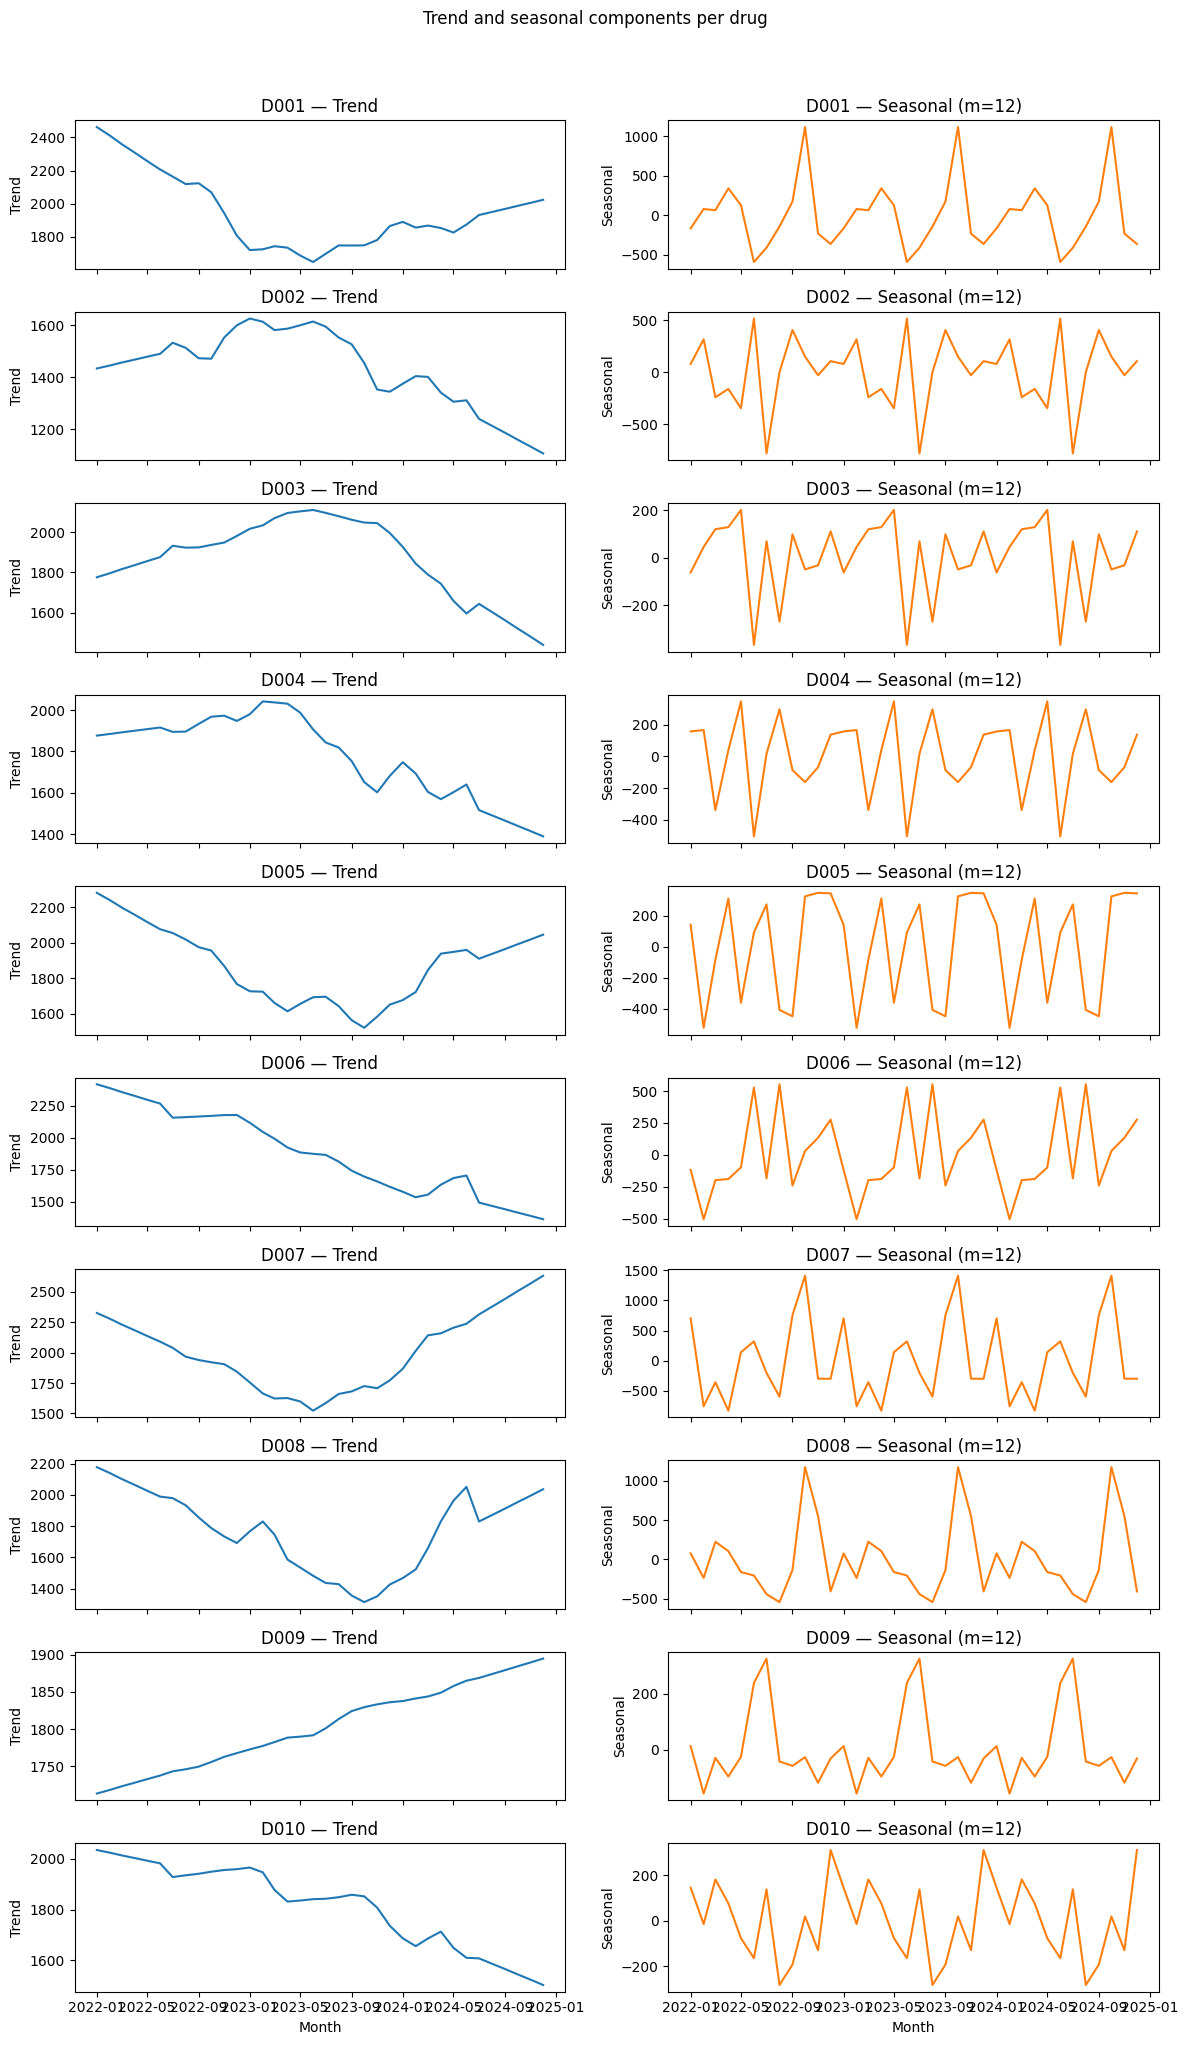

In [8]:
# Decomposition for all drugs (grid of trend + seasonal)
fig, axes = plt.subplots(n_drugs, 2, figsize=(12, 2 * n_drugs), sharex="col")
if n_drugs == 1:
    axes = axes.reshape(1, -1)
for i, drug_id in enumerate(drug_ids):
    decomp = decompose_drug(df, drug_id, period=12)
    axes[i, 0].plot(decomp.trend, color="C0")
    axes[i, 0].set_ylabel("Trend")
    axes[i, 0].set_title(f"{drug_id} — Trend")
    axes[i, 1].plot(decomp.seasonal, color="C1")
    axes[i, 1].set_ylabel("Seasonal")
    axes[i, 1].set_title(f"{drug_id} — Seasonal (m=12)")
axes[-1, 0].set_xlabel("Month")
axes[-1, 1].set_xlabel("Month")
plt.suptitle("Trend and seasonal components per drug", y=1.02)
plt.tight_layout()
plt.show()